In [1]:
#!pip install matplotlib

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Example using One machine with multiple GPUs

# Check if CUDA is available and number of GPUs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"
print(f"Using device: {device}")

# Check number of GPUs available
n_gpus = torch.cuda.device_count()
print(f"Number of GPUs available: {n_gpus}")

Using device: cuda
Number of GPUs available: 2


In [2]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED) # or torch.xpu.manual_seed_all, etc

In [3]:
#BATCH_SIZE = 32
BATCH_SIZE = 1024


# Simple network to train
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(10, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Create dummy data for training
X = torch.randn(1000, 10)  # 1000 samples, 10 features
y = torch.randn(1000, 1)   # 1000 labels

dataset = TensorDataset(X, y)


In [26]:
import time

def training(device, dataloader, epochs):

    num_epochs = epochs

    start = time.time_ns()
    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0
    
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move data to the same device as the model
        
            optimizer.zero_grad()  # Zero the gradients
        
            outputs = model(inputs)  # Forward pass
            loss = criterion(outputs, labels)  # Compute the loss
        
            loss.backward()  # Backpropagation
            optimizer.step()  # Update the model parameters
        
            running_loss += loss.item()

        #print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(dataloader):.4f}")


    end = time.time_ns()
    msecs_taken = (end-start)/1000000
    #print(f"Training complete. Time taken: {msecs_taken} msecs") 
    return msecs_taken

In [24]:
device_cpu = torch.device("cpu", 0)
model = SimpleNN()
model = nn.DataParallel(model, device_ids=[0])

In [16]:
device_cpu = torch.device("cpu")
device_cpu

device(type='cpu')

In [35]:
# test with CPU
model = SimpleNN()
device = torch.device("cpu", 0)
model = nn.DataParallel(model, device_ids=[0])
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)
times_cpu = []
NUM_EPOCHS = 100
batch_sizes = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
for bs in batch_sizes:
    dataloader = DataLoader(dataset, batch_size=bs, shuffle=True)
    time_taken_cpu = training(device, dataloader, NUM_EPOCHS)
    times_cpu.append(time_taken_cpu)
    print(f"Training complete. Batch size={bs}. Time taken: {time_taken_cpu} msecs")

In [60]:
# test with SINGLE GPU
model = SimpleNN()
device = torch.device("cuda")
model = nn.DataParallel(model, device_ids=[0])
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)
times_gpu_0 = []
NUM_EPOCHS = 100
batch_sizes = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
#batch_sizes = [512, 1024, 2048, 4096, 8192, 16384, 32768]
for bs in batch_sizes:
    dataloader = DataLoader(dataset, batch_size=bs, shuffle=True, pin_memory=True)
    time_taken_gpu_0 = training(device, dataloader, NUM_EPOCHS)
    times_gpu_0.append(time_taken_gpu_0)
    print(f"Training complete. Batch size={bs}. Time taken: {time_taken_gpu_0} msecs")

Training complete. Batch size=8. Time taken: 10462.296505 msecs
Training complete. Batch size=16. Time taken: 5402.160601 msecs
Training complete. Batch size=32. Time taken: 3155.529429 msecs
Training complete. Batch size=64. Time taken: 1817.033744 msecs
Training complete. Batch size=128. Time taken: 1094.477247 msecs
Training complete. Batch size=256. Time taken: 669.058422 msecs
Training complete. Batch size=512. Time taken: 452.806313 msecs
Training complete. Batch size=1024. Time taken: 474.733663 msecs
Training complete. Batch size=2048. Time taken: 433.392292 msecs
Training complete. Batch size=4096. Time taken: 344.05052 msecs
Training complete. Batch size=8192. Time taken: 428.730067 msecs
Training complete. Batch size=16384. Time taken: 344.790232 msecs
Training complete. Batch size=32768. Time taken: 463.36159 msecs


In [64]:
# test with 2 GPU
model = SimpleNN()
device = torch.device("cuda")
model = nn.DataParallel(model, device_ids=[0,1])
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)
times_gpu = []
NUM_EPOCHS = 100
batch_sizes = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
for bs in [ 2*bs for bs in batch_sizes]:
    dataloader = DataLoader(dataset, batch_size=bs, shuffle=True, pin_memory=True)
    time_taken_gpu = training(device, dataloader, NUM_EPOCHS)
    times_gpu.append(time_taken_gpu)
    print(f"Training complete. Batch size={bs}. Time taken: {time_taken_gpu} msecs")

Training complete. Batch size=16. Time taken: 19432.691881 msecs
Training complete. Batch size=32. Time taken: 10474.186073 msecs
Training complete. Batch size=64. Time taken: 5199.126957 msecs
Training complete. Batch size=128. Time taken: 2715.448768 msecs
Training complete. Batch size=256. Time taken: 1609.312138 msecs
Training complete. Batch size=512. Time taken: 859.08818 msecs
Training complete. Batch size=1024. Time taken: 694.705466 msecs
Training complete. Batch size=2048. Time taken: 660.78051 msecs
Training complete. Batch size=4096. Time taken: 550.571902 msecs
Training complete. Batch size=8192. Time taken: 661.914589 msecs
Training complete. Batch size=16384. Time taken: 556.67205 msecs
Training complete. Batch size=32768. Time taken: 662.124336 msecs
Training complete. Batch size=65536. Time taken: 671.548642 msecs


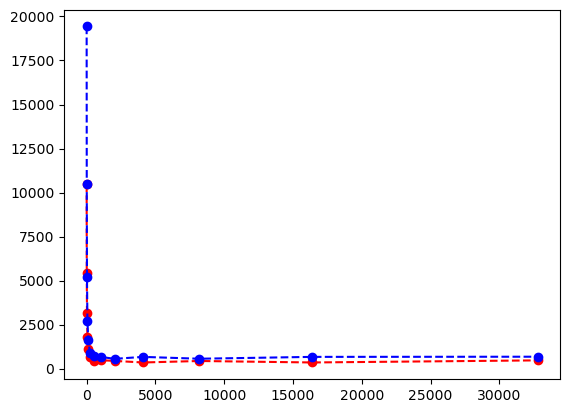

In [65]:
import matplotlib.pyplot as plt
plt.plot(batch_sizes,times_gpu_0,'ro')
plt.plot(batch_sizes,times_gpu_0,'r--')
plt.plot(batch_sizes,times_gpu,'bo')
plt.plot(batch_sizes,times_gpu,'b--')